In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from stochastique.models.FHN import model_FHN, equilibria_FHN
from stochastique.analysis.simulation import simulate_trajectory, simulate_stochastic_cloud

In [2]:
N_STEPS_DEFAULT = 1000

# 1. Проведем сравнение стохастических решений для $a = 1.1$, $a = 1.01$

(а) Построим графики $x(\varepsilon)$, пропустив переходный процесс $T = 100$.

In [3]:
# rng = np.random.default_rng()

# delta, a = 0.1, None
# a_values = [1.1, 1.01]

# time_span = np.linspace(0, 100, num=10 ** 4)
# noise_mask = np.array([1, 0])   # add noise to 1st equation only
# eps_values = np.linspace(0, 1, num=100)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# for a, ax in zip(a_values, axes):
#     x_values = np.empty_like(eps_values)
#     params = dict(delta=delta, a=a)

#     for idx in tqdm(range(len(eps_values)), desc='Simulate for different epsilon values'):
#         state_init = equilibria_FHN(**params)[0]
#         trajectory = simulate_trajectory(
#             model_func=model_FHN,
#             params=params,
#             state_init=state_init,
#             time_span=time_span,
#             epsilon=eps_values[idx],
#             noise_mask=noise_mask,
#             rng=rng,
#         )
#         trajectory = trajectory[100:]   # clip transient
#         trajectory_x = trajectory[:, 0]
#         x_values[idx] = np.max(trajectory_x)

#     ax.plot(eps_values, x_values)
#     ax.set_title(rf'$\delta$ = {delta}, $a$ = {a}')
#     ax.set_xlabel(r'$\varepsilon$')
#     ax.set_ylabel(r'$x$')

Локализуем $\varepsilon$ зоны стохастического возбуждения.

Run multiple simulations: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]


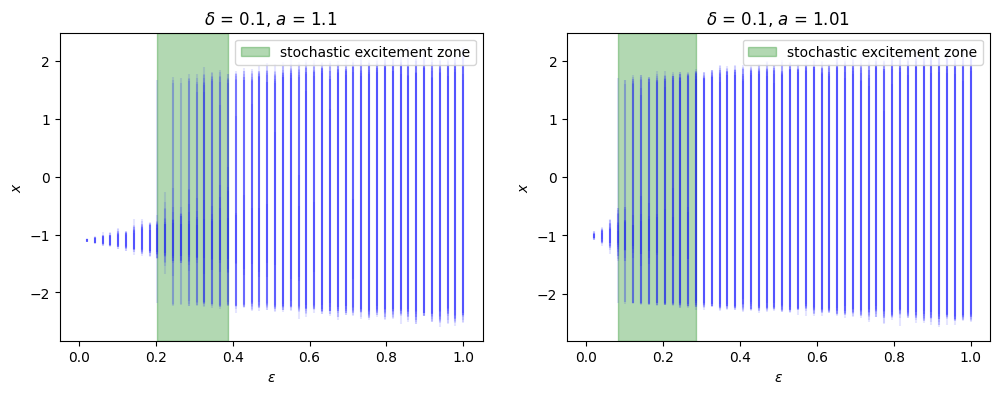

In [4]:
from stochastique.analysis.excitement import localize_stochastic_excitement_zones

# rng = np.random.default_rng()

# delta, a = 0.1, 1.01
# params = dict(delta=delta, a=a)


# time_span = np.linspace(0, 100, num=10 ** 3)
# noise_mask = np.array([1, 0])   # add noise to 1st equation only
# eps_values = np.linspace(0, 1, num=100)

# fig, ax = plt.subplots()

rng = np.random.default_rng()

delta, a = 0.1, None
a_values = [1.1, 1.01]

time_span = np.linspace(0, 10, num=10 ** 3)
noise_mask = np.array([1, 0])   # add noise to 1st equation only
eps_values = np.linspace(0, 1, num=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a, ax in zip(a_values, axes):
    params = dict(delta=delta, a=a)
    state_init = equilibria_FHN(**params)[0]

    localize_stochastic_excitement_zones(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        noise_mask=noise_mask,
        eps_values=eps_values,
        num_simulations=10,
        rng=rng,
        ax=ax,
    )

    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a}')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel(r'$x$')
    ax.legend()

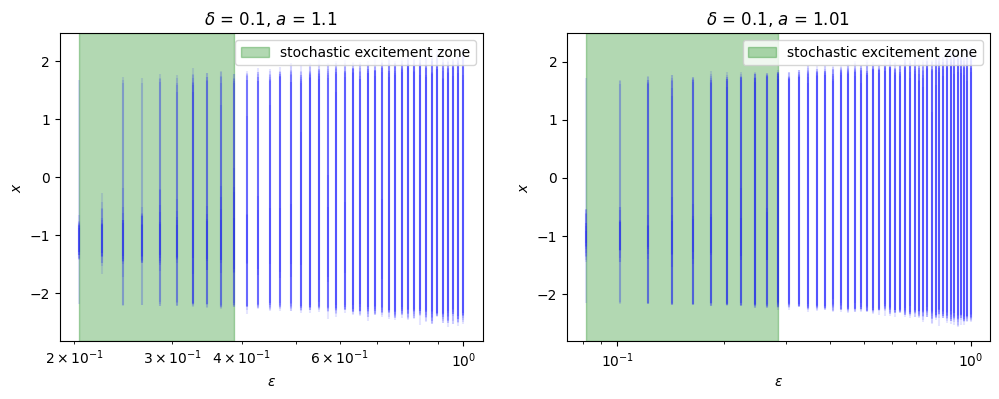

In [5]:
for ax in axes:
    ax.set_xscale('log')

fig

(б) Построим временные ряды при различных значениях $\varepsilon$: с возбуждением и без возбуждения.

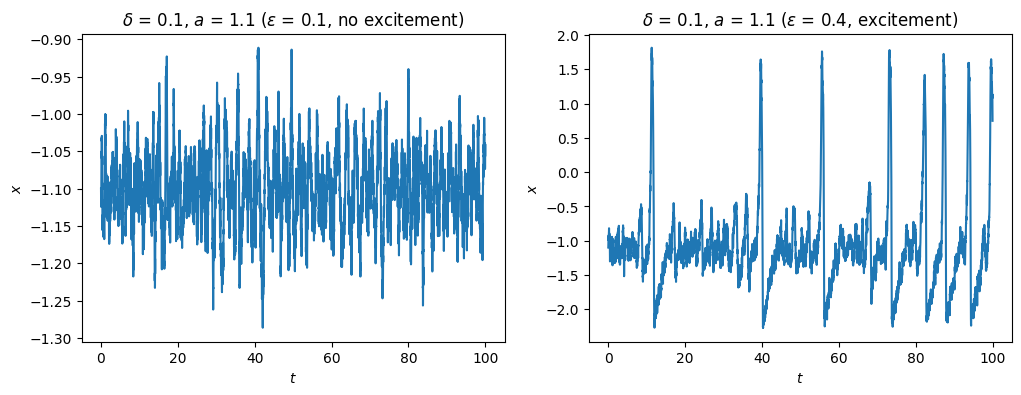

In [16]:
rng = np.random.default_rng()

delta, a = 0.1, 1.1
eps_values = [
    (0.1, 'no excitement'),
    (0.4, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    params = dict(delta=delta, a=a)

    state_init = equilibria_FHN(**params)[0]
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )
    # trajectory = trajectory[100:]   # clip transient
    trajectory_x = trajectory[:, 0]
    
    ax.plot(time_span, trajectory_x)
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$x$')

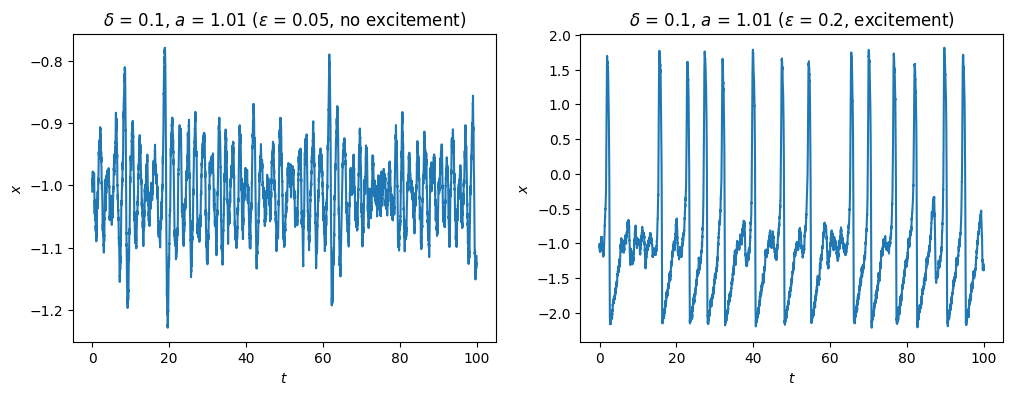

In [20]:
rng = np.random.default_rng()

delta, a = 0.1, 1.01
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    params = dict(delta=delta, a=a)

    state_init = equilibria_FHN(**params)[0]
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )
    # trajectory = trajectory[100:]   # clip transient
    trajectory_x = trajectory[:, 0]
    
    ax.plot(time_span, trajectory_x)
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$x$')

# 2. Построим доверительные эллипсы в допороговой и надпороговой зонах для $a = 1.1$, $a = 1.01$

In [ ]:
from stochastique.core.numerical import stochastic_sensitivity_matrix_2d
from stochastique.util.plot import plot_confidence_ellipse_2d

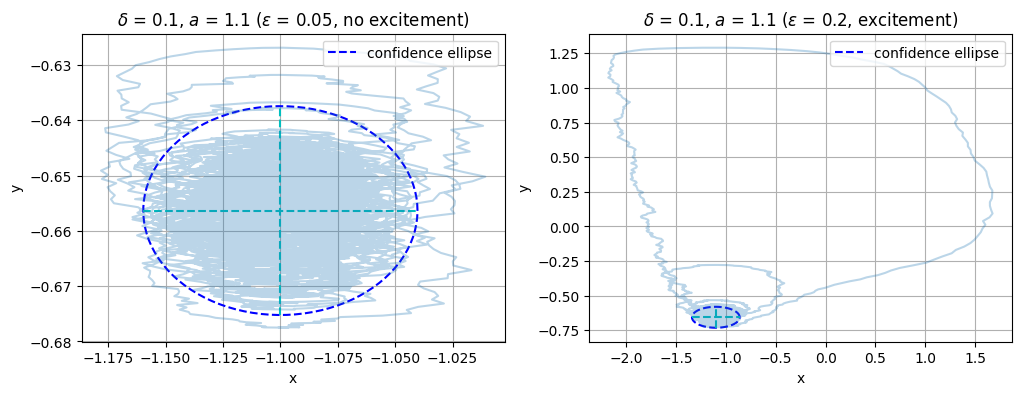

In [30]:
delta, a = 0.1, 1.1
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

# eps, comment = eps_values[0]
params = dict(delta=delta, a=a)
equilibrium = equilibria_FHN(**params)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium,
        W=W,
        epsilon=eps,
        major_axes=True,
    )

    ax.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.3, label='trajectory')
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')

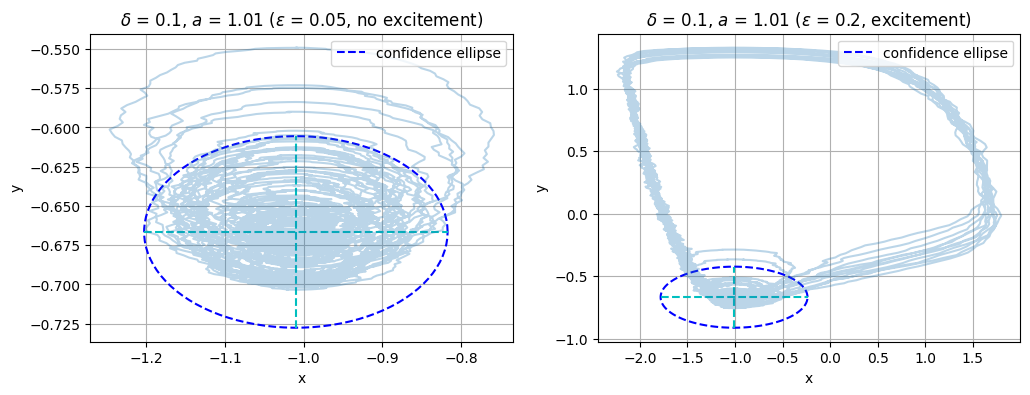

In [31]:
delta, a = 0.1, 1.01
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

# eps, comment = eps_values[0]
params = dict(delta=delta, a=a)
equilibrium = equilibria_FHN(**params)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium,
        W=W,
        epsilon=eps,
        major_axes=True,
    )

    ax.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.3, label='trajectory')
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')